In [48]:
#数据导入及处理缺失值
#Data import and handling of missing values
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

# 加载数据
# load data
data = fetch_california_housing()

X = data.data          # 特征值eigenvalue
y = data.target        # 目标值（房价）Target value (house price)

feature_names = data.feature_names

# Transfer to DataFrame（推荐，方便后续操作）
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name="MedHouseVal")

print(X.head())
print(y.head())
print("Shape of X:", X.shape)

# ===== 处理缺失值 =====
#Handling Missing Values
print("Missing values before cleaning:")
print(X.isnull().sum())

# 删除含缺失值的行（如果有）
# Delete rows with missing values (if any).
X = X.dropna()
y = y.loc[X.index]   # 保持 X 和 y 对齐 Align X and Y

print("Shape after removing missing values:", X.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64
Shape of X: (20640, 8)
Missing values before cleaning:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Shape after removing missing values: (20640, 8)


In [49]:
#Baseline Modal
#Data preprocessing and division of training，validation and test set
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# 先从X特征值，y房价 中分出 test 和 train_val两个数据集
# First, separate the "X feature values" and "y house prices" into two datasets: "test" and "train_val".
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=26
)
# X_train_val → 80% 的特征，X_test → 20% 的特征，y_train_val → 80% 的标签，y_test → 20% 的标签
# X_train_val → 80% of the features, X_test → 20% of the features, 
# y_train_val → 80% of the labels, y_test → 20% of the labels

# 从X_train_val, y_train_val里再分 validation（分成X_train, X_val, y_train, y_val）
# From X_train_val and y_train_val, further divide into validation (resulting in X_train, X_val, y_train, y_val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=26
)#这里的0.1是train_val80%里的10%
#Here, 0.1 refers to the 10% within the "train_val 80%" portion.


# 在标准化前，先保存 raw（未标准化）版本：后面kNN需要用原始经纬度
# Before standardization, save the raw (unstandardized) version first: 
# the kNN algorithm later will require the original latitude and longitude values.
X_train_raw = X_train.copy()
X_val_raw   = X_val.copy()
X_test_raw  = X_test.copy()

# scale (fit only on train) and then convert it back to a DataFrame#标准化（只在训练集）并转回DataFrame
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns,index=X_train_raw.index)
X_val   = pd.DataFrame(scaler.transform(X_val), columns=X.columns,index=X_val_raw.index)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test_raw.index)
#scaler.transform 标准化 test 数据 means to Standardized test data
#index=X_test_raw.index Pandas 会默认生成新的 0~n 索引 Pandas will automatically generate new indices ranging from 0 to n.
#Add index=...，这样索引不会乱（对齐 y / 后面 debug 更稳）so the index won't be disordered (it will be more stable when aligning y / and then the debug part).

Architecture: (32,), Activation: tanh, Validation MSE: 0.3137
Architecture: (32,), Activation: relu, Validation MSE: 0.3262
Architecture: (32,), Activation: logistic, Validation MSE: 0.3210
Architecture: (64,), Activation: tanh, Validation MSE: 0.3140
Architecture: (64,), Activation: relu, Validation MSE: 0.3272


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Architecture: (64,), Activation: logistic, Validation MSE: 0.3124
Architecture: (64, 32), Activation: tanh, Validation MSE: 0.2841
Architecture: (64, 32), Activation: relu, Validation MSE: 0.2890


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Architecture: (64, 32), Activation: logistic, Validation MSE: 0.3358
Architecture: (128, 32), Activation: tanh, Validation MSE: 0.2789
Architecture: (128, 32), Activation: relu, Validation MSE: 0.2775
Architecture: (128, 32), Activation: logistic, Validation MSE: 0.2899
Architecture: (128, 64), Activation: tanh, Validation MSE: 0.2798
Architecture: (128, 64), Activation: relu, Validation MSE: 0.2793
Architecture: (128, 64), Activation: logistic, Validation MSE: 0.2855
Architecture: (128, 64, 32), Activation: tanh, Validation MSE: 0.3139
Architecture: (128, 64, 32), Activation: relu, Validation MSE: 0.2987
Architecture: (128, 64, 32), Activation: logistic, Validation MSE: 0.3156

=== Validation MSE Table ===
Activation     logistic      relu      tanh
Architecture                               
(32,)          0.320968  0.326200  0.313691
(64,)          0.312351  0.327152  0.313980
(64, 32)       0.335811  0.289044  0.284061
(128, 32)      0.289895  0.277486  0.278872
(128, 64)      0.28

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


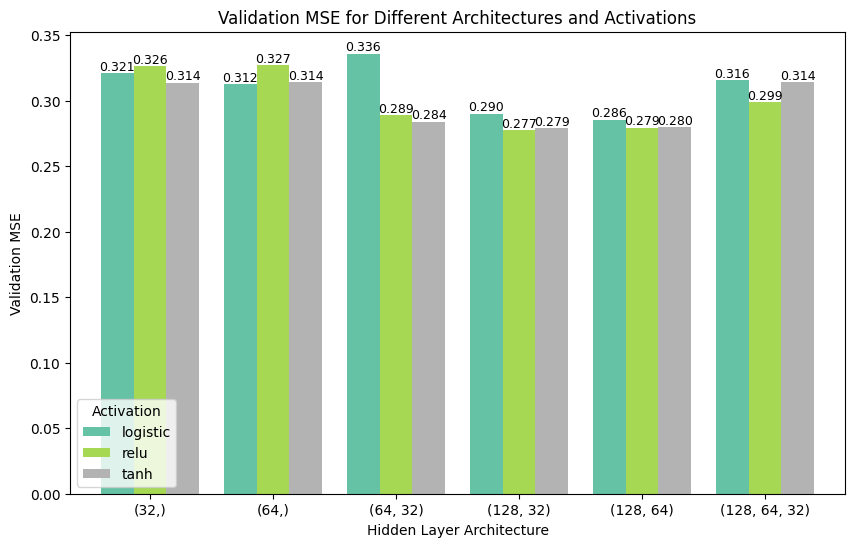

In [50]:
#寻找最优隐藏层与激活函数
#Search for the optimal hidden layer and activation function
import matplotlib.pyplot as plt
# 1) Define architectures and activation functions
#  定义不同的神经网络结构和激活函数
# ============================================================

# Each tuple represents the number of neurons in hidden layers.
# Example:
# (64,32) means two hidden layers with 64 and 32 neurons.
#
# 每个元组表示隐藏层结构。
# 例如：
# (64,32) 表示两个隐藏层，分别有 64 和 32 个神经元。

architectures = [
    (32,),
    (64,),
    (64,32),
    (128,32),
    (128,64),
    (128,64,32)
]

# Activation functions to test.
# tanh  → nonlinear symmetric activation
# relu  → widely used deep learning activation
# logistic → sigmoid nonlinear activation
#
# 要测试的激活函数：
# tanh → 对称的非线性函数
# relu → 深度学习中常用激活函数
# logistic → Sigmoid 非线性激活函数

activations = ['tanh', 'relu', 'logistic']


# ============================================================
# 2) Train models and collect Test MSE
# 训练模型并记录测试集 MSE
# ============================================================

results = []

for arch in architectures:
    for act in activations:

        
        # Create a neural network model with the current architecture
        # and activation function.
        #
        # 创建一个神经网络模型，使用当前的隐藏层结构和激活函数

        model_test_act = MLPRegressor(
            hidden_layer_sizes=arch,
            activation=act,
            solver='adam',
            learning_rate_init=1e-3,
            max_iter=700,
            early_stopping=False,
            random_state=26
        )

        
        # Train the model on the training dataset.
        # 在训练集上训练模型

        model_test_act.fit(X_train, y_train)

        
        # Predict house prices on the validation set
        # 在验证集上进行预测

        val_pred_act = model_test_act.predict(X_val)

        # Compute Mean Squared Error (MSE) on validation set
        # 计算验证集上的均方误差

        val_mse_act = mean_squared_error(y_val, val_pred_act)

        results.append({
            'Architecture': str(arch),
            'Activation': act,
            'Validation_MSE': val_mse_act
        })

        print(f"Architecture: {arch}, Activation: {act}, Validation MSE: {val_mse_act:.4f}")

# ============================================================
# 3) Convert results to DataFrame
# 将结果转换为表格
# ============================================================

# 
# Convert the results list into a pandas DataFrame
# and reshape it using pivot for easier visualization.
#

# 将实验结果转换为 DataFrame，
# 再使用 pivot 变成适合绘图的格式。

results_df = pd.DataFrame(results)

pivot_table = results_df.pivot(
    index='Architecture',
    columns='Activation',
    values='Validation_MSE'
)

# -------------------------------------------------
# Arrange the architecture according to the complexity of the hidden layers
# 按隐藏层的复杂程度进行排列架构
# -------------------------------------------------

order = ['(32,)', '(64,)', '(64, 32)', '(128, 32)','(128, 64)', '(128, 64, 32)']
pivot_table = pivot_table.reindex(order)

print("\n=== Validation MSE Table ===")
print(pivot_table)


# ============================================================
# 4) Plot grouped bar chart
#  绘制分组柱状图
# ============================================================

# Create a grouped bar chart showing Validation MSE for each
# architecture and activation combination.
#

# 绘制分组柱状图，
# 展示不同隐藏层结构和激活函数组合的 Validation MSE。

ax = pivot_table.plot(
    kind='bar',
    figsize=(10,6),
    width=0.8,
    colormap='Set2'
)

plt.ylabel("Validation MSE")
plt.xlabel("Hidden Layer Architecture")
plt.title("Validation MSE for Different Architectures and Activations")
plt.xticks(rotation=0)
plt.legend(title="Activation")




# ------------------------------------------------------------
# Add value labels above bars using patches
# 使用 patches 自动获取每个柱子的位置，避免坐标误差
# ------------------------------------------------------------

  
    # Place text at the center top of each bar
    # 在每个柱子的顶部中心位置标注数值

# Add value labels above bars
for p in ax.patches:
    height = p.get_height()# 获取柱子的高度（MSE值）Get bar height (MSE value)
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()


In [ ]:
#这个代码块还没修改好，最终预测可能把val和train合起来一起train？
'''
# 重新fit scaler：这次用整个 train_val
scaler_final = StandardScaler()
X_train_val_scaled = pd.DataFrame(
    scaler_final.fit_transform(X_train_val),
    columns=X.columns,
    index=X_train_val.index
)
X_test_scaled = pd.DataFrame(
    scaler_final.transform(X_test),
    columns=X.columns,
    index=X_test.index
)
'''
# model (no internal early stopping, since you already have X_val)
model = MLPRegressor(
    hidden_layer_sizes=(128,32),
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=700,
    early_stopping=False,
    random_state=26
)

model.fit(X_train, y_train)
'''
model.fit(X_train_val_scaled, y_train_val)

test_pred = model.predict(X_test_scaled)
test_mse = mean_squared_error(y_test, test_pred)

print("Final Test MSE:", test_mse)
'''
#测试集和预测集的预测
#The predictions of the test set and the prediction set
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

# 训练集预测
#Training set prediction
train_pred = model.predict(X_train)
# 计算训练误差
# Calculate training error
train_mse = mean_squared_error(y_train, train_pred)

print("Baseline Train MSE:", train_mse)#加入是为了判断是不是欠拟合或者过拟合Joining is to determine whether it is underfitting or overfitting.
print("Validation MSE:", mean_squared_error(y_val, val_pred))#Mean Squared Error（均方误差）
print("Test MSE:", mean_squared_error(y_test, test_pred))

Baseline Train MSE: 0.22346115225375018
Validation MSE: 0.2788722368528284
Test MSE: 0.2503595555373939


In [ ]:
#luke的代码块

In [ ]:
# ============================================================
# 第二个模型：加入 neighbourhood feature（NeighbourPrice）
# ============================================================

from sklearn.neighbors import NearestNeighbors  # 用于找k个最近邻

K = 7  # 邻居数量k（你们分支实验可改成3/5/10，但一次实验只改k）找到距离它最近的 7 套房子

# ------------------------------------------------------------
# 1) 用训练集的经纬度建立 kNN（只fit训练集）
#    这样 val/test 找邻居时，也只会在 train 里找（避免用到test标签）
# ------------------------------------------------------------
knn = NearestNeighbors(n_neighbors=K+1)  # 创建kNN搜索器
knn.fit(X_train_raw[['Latitude', 'Longitude']])  # 只用训练集坐标来fit

def neighbour_mean_price(query_df, y_train_series, exclude_self=False):
    """
    为 query_df 的每个样本计算：训练集中k个邻居的 y 的平均值
    query_df: 需要计算邻居特征的数据（train/val/test 的 raw DataFrame）
    y_train_series: 训练集标签（只能用它，避免data leakage）
    exclude_self: 如果 query_df 是训练集本身，要剔除“自己”这个邻居
    """

    #这行代码的作用是把 y_train_series 的顺序重新排列，使它与 X_train_raw 的索引顺序完全一致，从而保证每一行特征对应正确的标签。
    y_train_series = y_train_series.loc[X_train_raw.index]
    #根据每个样本的经纬度，在训练集中找到最近的 K 个邻居，并返回这些邻居的距离 (dists) 和在训练集中的位置索引 (inds)
    dists, inds = knn.kneighbors(query_df[['Latitude', 'Longitude']])

    neigh_mean = [] ## 存放每个样本的邻居均价
    for row_i, idxs in enumerate(inds):
        if exclude_self:
            # 只剔除“自己这一行”的训练索引（最严谨），剔除自己（完全一样的那行数据）
            idxs = idxs[idxs != row_i]  # 用位置索引剔除自己
            idxs = idxs[:K]                 # 保证还是K个邻居，比如上一行代码要执行删除时，原数据并没有自己defensive programming（防御式编程）
            #比如以后用距离过滤，或者过滤多个点，不会变成 6 个或其他奇怪数量
        else:
            # val/test 直接取前K个邻居（它们全来自train）
            idxs = idxs[:K]
        # 用训练集的 y_train 取邻居价格并求平均（关键：不使用val/test真实y）
        neigh_mean.append(y_train_series.iloc[idxs].mean())

    return np.array(neigh_mean)
'''
觉得“我在训练集里拿某一条样本当 query，那 kNN 返回的邻居里怎么可能没有它自己？”
按数学定义，它应该一定在。
但你看到的 Case A（极少数）说明：在实现细节上，它“可能不在返回的前 K+1 个里”。
原因主要是 并列距离（tie）+ 只取前 K+1 个 + 内部取子集。

你并不是“先拿这一条样本再算平均”

你做的是：
用这条样本的经纬度作为 query
让 kneighbors() 在训练集里找 最接近的 n_neighbors 个点
返回这些点的索引
你再用这些索引去取 y_train 求平均

也就是说：
你并不是在邻居列表里手动把“自己”塞进去。
你完全依赖 kneighbors() 返回的那一组邻居
'''
# ------------------------------------------------------------
# 2) 计算 NeighbourPrice（邻居均价）
#    - train：剔除自己
#    - val/test：邻居都来自train，不存在“自己”，不用剔除
# ------------------------------------------------------------
neigh_price_train = neighbour_mean_price(X_train_raw, y_train, exclude_self=True)
neigh_price_val   = neighbour_mean_price(X_val_raw,   y_train, exclude_self=False)
neigh_price_test  = neighbour_mean_price(X_test_raw,  y_train, exclude_self=False)
#exclude_self=True 每个样本最近的点一定是自己，所以删除自己
#验证集样本根本不在训练集中，所以后面不需要删除自己

'''
| 变量          | 作用              |
| ----------- | --------------- |
| `X_val_raw` | 查询点（我想知道它附近房价）  |
| `y_train`   | 数据库（我用它来查邻居的价格） |
'''

# ------------------------------------------------------------
# 3) 把新特征train,val和test 的 neighbour price 加到 raw 数据里，做成新列（注意：从 raw 开始加）
# ------------------------------------------------------------
X_train_enh_raw = X_train_raw.copy()
X_val_enh_raw   = X_val_raw.copy()
X_test_enh_raw  = X_test_raw.copy()

X_train_enh_raw['NeighbourPrice'] = neigh_price_train
X_val_enh_raw['NeighbourPrice']   = neigh_price_val
X_test_enh_raw['NeighbourPrice']  = neigh_price_test

# ------------------------------------------------------------
# 4) 新增列后必须重新标准化（仍然只fit train）
# ------------------------------------------------------------
scaler2 = StandardScaler()
X_train_enh = pd.DataFrame(scaler2.fit_transform(X_train_enh_raw), columns=X_train_enh_raw.columns,index=X_train_enh_raw.index)
X_val_enh   = pd.DataFrame(scaler2.transform(X_val_enh_raw), columns=X_val_enh_raw.columns,index=X_val_enh_raw.index)
X_test_enh  = pd.DataFrame(scaler2.transform(X_test_enh_raw), columns=X_test_enh_raw.columns,index=X_test_enh_raw.index)

# ------------------------------------------------------------
# 5) 训练第二个模型（参数保持与baseline一致，保证公平对比）
# ------------------------------------------------------------
model_enh = MLPRegressor(
    hidden_layer_sizes=(64, 32),      # 与baseline相同
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=False,
    random_state=26
)

model_enh.fit(X_train_enh, y_train)

# ------------------------------------------------------------
# 6) 评估第二个模型
# ------------------------------------------------------------
val_pred_enh  = model_enh.predict(X_val_enh)
test_pred_enh = model_enh.predict(X_test_enh)

enh_val_mse  = mean_squared_error(y_val, val_pred_enh)
enh_test_mse = mean_squared_error(y_test, test_pred_enh)

train_pred_enh = model_enh.predict(X_train_enh)
enh_train_mse = mean_squared_error(y_train, train_pred_enh)

print("Enhanced Train MSE:", enh_train_mse)
print("Enhanced Validation MSE:", enh_val_mse)#模型在验证集上的平均平方误差是 0.222
print("Enhanced Test MSE:", enh_test_mse)#模型在最终测试集上的平均平方误差是 0.1835

# ------------------------------------------------------------
# 7) 和 baseline 对比（负数表示Enhanced更好）
# ------------------------------------------------------------
print("Delta Test MSE (Enhanced - Baseline):", enh_test_mse - mean_squared_error(y_test, test_pred))
#报告思路是我探索不同领域的参数a=，b=，c=

Enhanced Train MSE: 0.16227939588113074
Enhanced Validation MSE: 0.21618565935594575
Enhanced Test MSE: 0.17794248478639452
Delta Test MSE (Enhanced - Baseline): -0.07022940841119521
